## Bias–Variance Tradeoff

A degree-15 polynomial can fit 30 training points almost perfectly — and still be useless on new data. **Why does more complexity sometimes make predictions worse?**

In this lesson we learn to:

- Recognize **under-fitting** (high bias) and **over-fitting** (high variance) from model curves and scores.
- Estimate **generalization performance** with **cross-validation** instead of a single train/test split.
- Compare models of different complexity using **cross-validated MAE**.

![Bias–variance tradeoff](../assets/bias-variance_tradeoff.png)

In [1]:
from pathlib import Path

# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
from sklearn.pipeline import Pipeline

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
from sklearn.preprocessing import PolynomialFeatures

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn.linear_model import LinearRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html
from sklearn.dummy import DummyRegressor

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html
from sklearn.model_selection import cross_validate

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
from sklearn.model_selection import KFold

### Synthetic non-linear data

We generate 30 points from a **quadratic** function plus noise. The true relationship is curved, so a straight line will underfit and a very high-degree polynomial may overfit.

In [2]:
np.random.seed(11)

n_samples = 30
X = 6 * np.random.rand(n_samples, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(n_samples, 1)

data_df = pd.DataFrame({"X": X.ravel(), "y": y.ravel()})
data_df.head()

,X,y
0,-1.918382,3.017342
1,-2.883149,2.963548
2,-0.220689,2.529415
3,1.349604,5.809390
4,-0.478778,2.265916


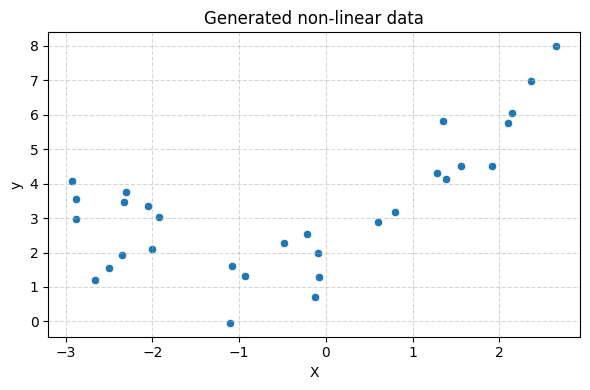

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.scatterplot(
    data=data_df,
    x="X",
    y="y",
    ax=ax,
)
ax.set_title("Generated non-linear data")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Fit models of increasing complexity

We compare four regressors:

- **Dummy (mean)**: always predicts the training mean — high bias, simplest baseline.
- **Degree 1**: linear fit — still too simple for curved data.
- **Degree 2**: matches the true quadratic form — should generalize well.
- **Degree 9**: very flexible — can memorize training noise (high variance).

In [14]:
models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Degree 1": Pipeline([
        ("poly", PolynomialFeatures(degree=1)),
        ("regressor", LinearRegression()),
    ]),
    "Degree 2": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("regressor", LinearRegression()),
    ]),
    "Degree 9": Pipeline([
        ("poly", PolynomialFeatures(degree=9)),
        ("regressor", LinearRegression()),
    ]),
}

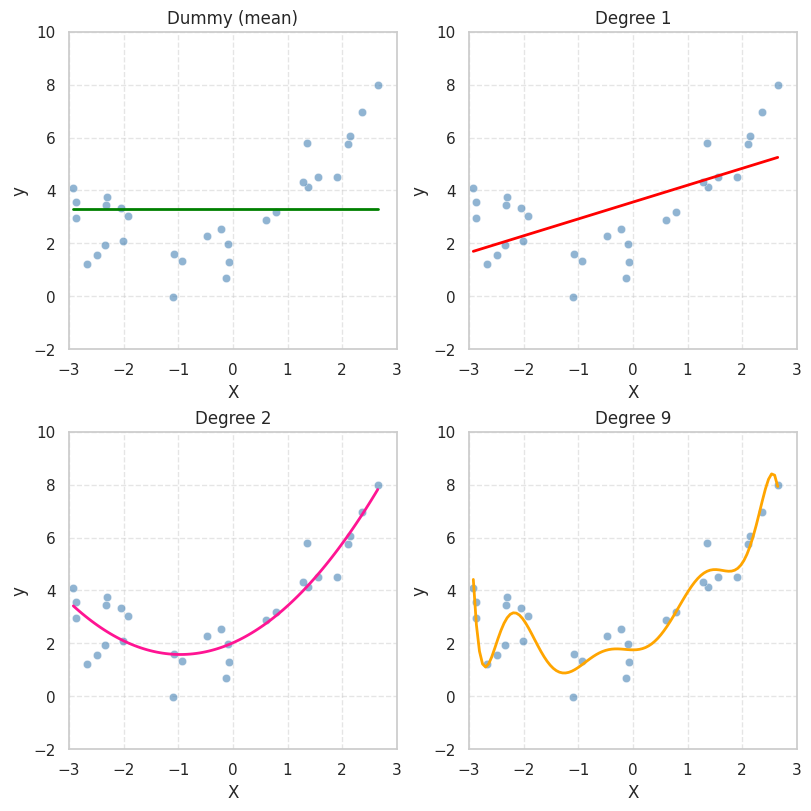

In [15]:
X_plot = np.linspace(X.min(), X.max(), num=100).reshape(-1, 1)
plot_df = pd.DataFrame({"X": X_plot.ravel()})

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 8),
    constrained_layout=True,
)
axes = axes.flatten()

curve_colors = ["green", "red", "deeppink", "orange"]

for axis, (name, model), color in zip(axes, models.items(), curve_colors):
    model.fit(X, y)
    y_plot = model.predict(X_plot)

    sns.scatterplot(
        data=data_df,
        x="X",
        y="y",
        color="steelblue",
        alpha=0.6,
        ax=axis,
    )
    axis.plot(X_plot, y_plot, color=color, linewidth=2)
    axis.set_xlim(-3, 3)
    axis.set_ylim(-2, 10)
    axis.grid(True, linestyle="--", alpha=0.5)
    axis.set_title(name)

plt.show()

## Estimating generalization with cross-validation

**Cross-validation (CV)** estimates how well a model generalizes **without touching the held-out test set**. The training data is split repeatedly into train/validation folds; each fold scores the model on data it did not train on.

![K-fold cross-validation in parallel](../assets/cv_parallel.png)

We pass a CV strategy to [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) via the `cv` parameter:

In [16]:
k_fold = KFold(
    n_splits=10,       # split training data into 10 folds
    shuffle=True,      # randomize row order before splitting
    random_state=42,   # reproducible fold assignments
)

cv_results = cross_validate(
    estimator=models["Degree 1"],
    X=X,
    y=y,
    cv=k_fold,
    # Train and score each fold on a separate CPU core (-1 = all cores).
    n_jobs=-1,
    # sklearn scores must be "higher is better", so MAE is negated.
    scoring="neg_mean_absolute_error",
    return_train_score=True,
)

With `n_jobs=-1`, each fold runs on its own worker:

```{mermaid}
graph LR
  A[Training Data] -->|Split 1| B1[Worker 1]
  A -->|Split 2| B2[Worker 2]
  A -->|Split 3| B3[Worker 3]
  A -->|"..."| B4["..."]
  A -->|Split 10| B10[Worker 10]
  B1 -- Score --> C[Aggregate Scores]
  B2 -- Score --> C
  B3 -- Score --> C
  B4 -- Score --> C
  B10 -- Score --> C
```

Inspect scores for the linear model (Degree 1). We flip the sign back to get **MAE** (lower is better):

In [17]:
cv_df = pd.DataFrame(cv_results)
cv_df["test_score"] = -cv_df["test_score"]
cv_df["train_score"] = -cv_df["train_score"]

cv_df[["train_score", "test_score"]]

,train_score,test_score
0,1.247079,1.200327
1,1.133809,2.081100
2,1.190744,1.395644
3,1.206733,1.268993
4,1.244861,0.978988
5,1.221691,1.288539
6,1.270247,0.699780
7,1.162073,2.126412
8,1.266994,0.981411
9,1.194800,1.419145


Now cross-validate **all four models** and collect per-fold train and validation scores:

In [18]:
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=k_fold,
        n_jobs=-1,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
    )

    for train_mae in -scores["train_score"]:
        cv_results.append({"Model": name, "Score": train_mae, "Type": "train"})

    for test_mae in -scores["test_score"]:
        cv_results.append({"Model": name, "Score": test_mae, "Type": "test"})

results_df = pd.DataFrame(cv_results)
results_df

,Model,Score,Type
0,Dummy (mean),1.558206,train
1,Dummy (mean),1.320230,train
2,Dummy (mean),1.414550,train
3,Dummy (mean),1.584819,train
4,Dummy (mean),1.439854,train
...,...,...,...
75,Degree 9,0.485341,test
76,Degree 9,0.825150,test
77,Degree 9,1.045166,test
78,Degree 9,0.717171,test


### Compare models by cross-validated MAE

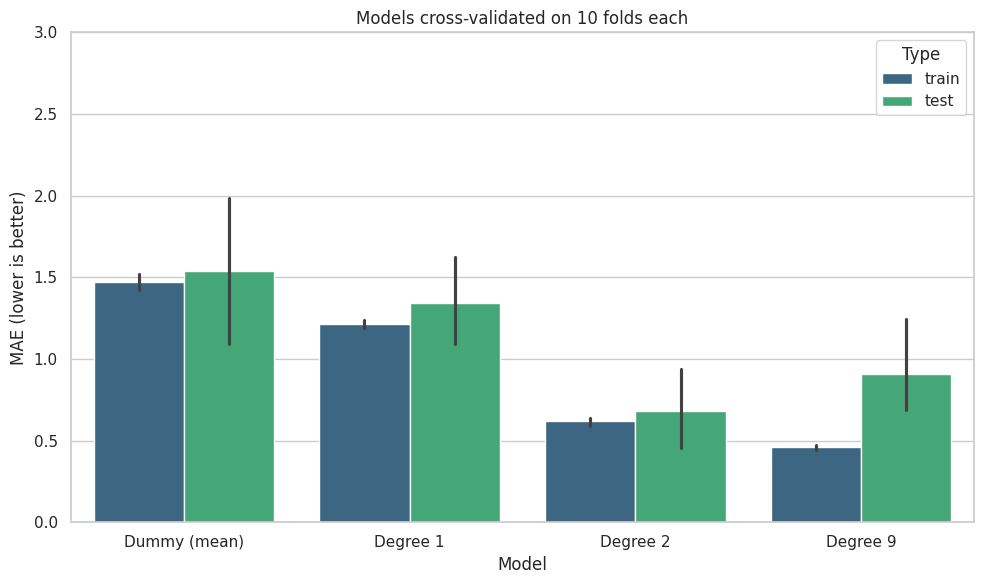

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=results_df,
    x="Model",
    y="Score",
    hue="Type",
    palette="viridis",
    ax=ax,
)

ax.set_title("Models cross-validated on 10 folds each")
ax.set_ylabel("MAE (lower is better)")
ax.set_xlabel("Model")
ax.set_ylim(0, 3)
plt.tight_layout()
plt.show()